# Gang dur Züri: Statistische Kennzahlen für Schulen

### Kurzbeschreibung
Aktuelle Kennzahlen für Schulen zu Stadt Zürich, Stadtkreisen und Stadtquartieren. Themengebiete: Stadtgebiet, Bildung und Freizeit, Bevölkerung und Gesellschaft, Bauen und Wohnen, Wirtschaft und Arbeit, Verkehr.

Die Daten werden jährlich aktualisiert, sodass Lehrpersonen für ihre Unterrichtsunterlagen stets aktuelle Zahlen verwenden können.

Datum: 25.06.2024


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005

### Importiere die notwendigen Packages

In [91]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [92]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [93]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [94]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [95]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [96]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [97]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [98]:
package_name = "prd_ssz_gang-dur-zueri_od1005"

In [99]:
data2betested= mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV100OD1005"    
    , datums_attr = None #['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005/download/BEV100OD1005.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005 

data_source: web


#### Teste INT mit eigenem Dataframe

In [100]:
data2betested_int = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV100OD1005"    
    , datums_attr = None #['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_prd_ssz_gang-dur-zueri_od1005/download/BEV100OD1005.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_prd_ssz_gang-dur-zueri_od1005 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/prd_ssz_gang-dur-zueri_od1005 

data_source: web


In [101]:
data2betested.head(6).T

,0,1,2,3,4,5
RaumNr,0,1,2,3,4,5
Raum,Ganze Stadt,Kreis 1,Kreis 2,Kreis 3,Kreis 4,Kreis 5
Oberthema,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet
Zahl,92,2,11,9,3,2
Thema,Fläche in Quadratkilometer,Fläche in Quadratkilometer,Fläche in Quadratkilometer,Fläche in Quadratkilometer,Fläche in Quadratkilometer,Fläche in Quadratkilometer
Vergleichszahl,12869,252,1550,1212,407,280
Vergleichstext,Anzahl Fussballfelder,Anzahl Fussballfelder,Anzahl Fussballfelder,Anzahl Fussballfelder,Anzahl Fussballfelder,Anzahl Fussballfelder
Bemerkungen,Datenquelle: Gebäude- und Wohnungsregister (2023),Datenquelle: Gebäude- und Wohnungsregister (2023),Datenquelle: Gebäude- und Wohnungsregister (2023),Datenquelle: Gebäude- und Wohnungsregister (2023),Datenquelle: Gebäude- und Wohnungsregister (2023),Datenquelle: Gebäude- und Wohnungsregister (2023)


In [102]:
data2betested_int.head(2).T

,0,1
RaumNr,0,1
Raum,Ganze Stadt,Kreis 1
Oberthema,Stadtgebiet,Stadtgebiet
Zahl,92,2
Thema,Fläche in Quadratkilometer,Fläche in Quadratkilometer
Vergleichszahl,12869,252
Vergleichstext,Anzahl Fussballfelder,Anzahl Fussballfelder
Bemerkungen,Datenquelle: Gebäude- und Wohnungsregister (2024),Datenquelle: Gebäude- und Wohnungsregister (2024)


Berechne weitere Attribute falls notwendig

In [103]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        #Jahr = lambda x: x.StichtagDatJahr,
        #Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    )
data2betested.dtypes

RaumNr              int64
Raum               object
Oberthema          object
Zahl              float64
Thema              object
Vergleichszahl    float64
Vergleichstext     object
Bemerkungen        object
dtype: object

### Einfache Datentests

In [104]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RaumNr          2170 non-null   int64  
 1   Raum            2170 non-null   object 
 2   Oberthema       2170 non-null   object 
 3   Zahl            2159 non-null   float64
 4   Thema           2170 non-null   object 
 5   Vergleichszahl  237 non-null    float64
 6   Vergleichstext  2170 non-null   object 
 7   Bemerkungen     2170 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.0 MB


In [105]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 2,170 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [106]:
data2betested.describe()

,RaumNr,Zahl,Vergleichszahl
count,2170,2159,237
mean,487,2416,223
std,585,16950,899
min,0,0,0
25%,11,10,10
50%,410,64,38
75%,820,654,162
max,9990,514995,12869


In [107]:
#data2betested_int.describe()

Welches sind die Quartiere ohne Werte bei BEW?

In [108]:
data2betested[np.isnan(data2betested.Zahl)]

,RaumNr,Raum,Oberthema,Zahl,Thema,Vergleichszahl,Vergleichstext,Bemerkungen
1886,1230,Hirzenbach,Wirtschaft & Arbeit,NaN,Arztpraxen (Allgemeinmedizin und Fachärzte),NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1900,13,Unbekannt (Stadt Zürich),Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1906,230,Leimbach,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1908,310,Alt-Wiedikon,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1909,330,Friesenberg,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1911,410,Werd,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1913,440,Hard,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1914,510,Gewerbeschule,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1928,1020,Wipkingen,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."
1929,1110,Affoltern,Wirtschaft & Arbeit,NaN,Zahnarztpraxen,NaN,Keine Vergleichszahl,"Datenquelle: STATENT (2021, Daten 1,\t\t\t\twe..."


In [109]:
#data2betested_int[np.isnan(data2betested_int.Zahl)]

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [110]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [111]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,RaumNr,Zahl,Vergleichszahl
count,"2,170","2,159",237
mean,487,"2,416",223
std,585,"16,950",899
min,0,0,0
25%,11,10,10
50%,410,64,38
75%,820,654,162
max,"9,990","514,995","12,869"


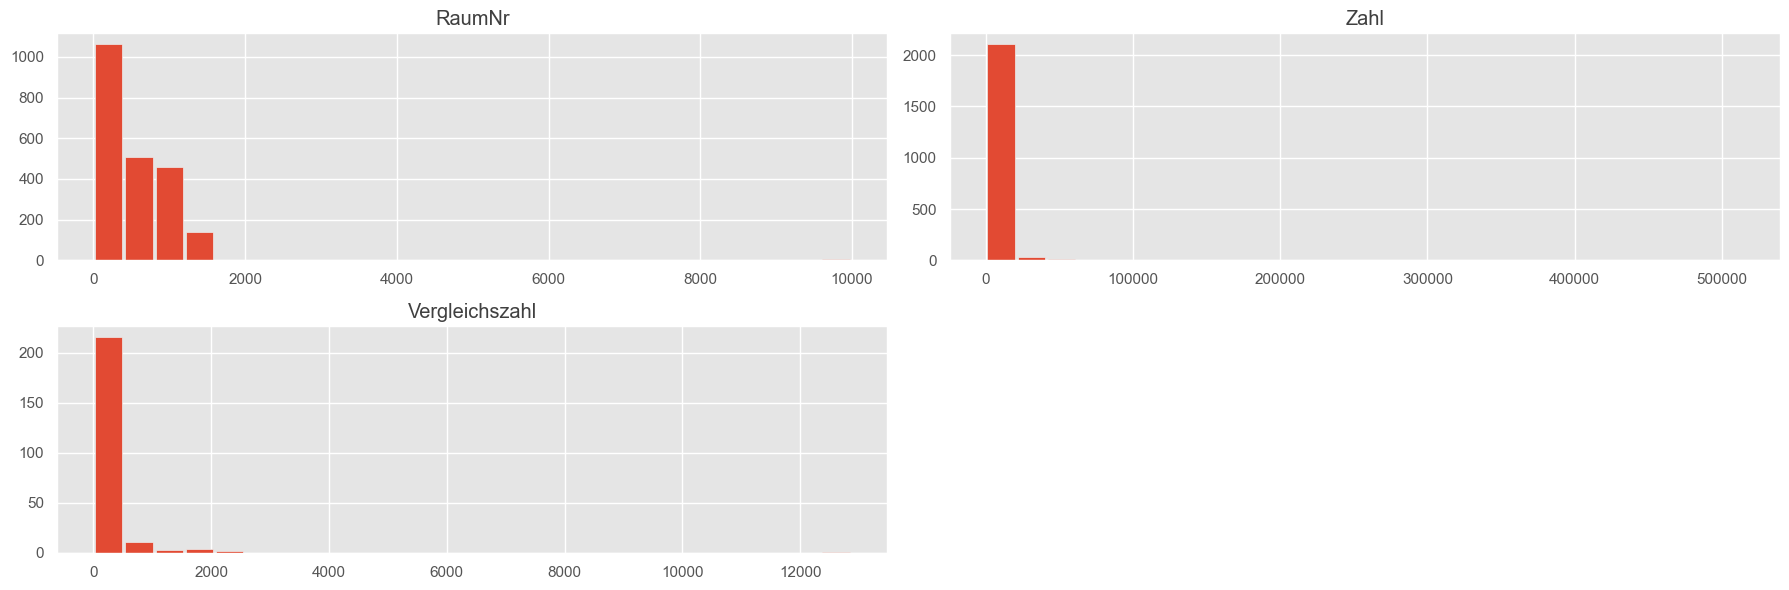

In [112]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [113]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,RaumNr,Raum,Oberthema,Zahl,Thema,Vergleichszahl,Vergleichstext,Bemerkungen


### Nullwerte und Missings?

In [114]:
data2betested.isnull().sum()

RaumNr               0
Raum                 0
Oberthema            0
Zahl                11
Thema                0
Vergleichszahl    1933
Vergleichstext       0
Bemerkungen          0
dtype: int64

In [115]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [116]:
data2betested.columns
#data2betested_int.columns

Index(['RaumNr', 'Raum', 'Oberthema', 'Zahl', 'Thema', 'Vergleichszahl', 'Vergleichstext',
       'Bemerkungen'],
      dtype='object')

In [117]:
data2betested.Oberthema.unique()

array(['Stadtgebiet', 'Bildung & Freizeit', 'Bevölkerung & Gesellschaft',
       'Bauen & Wohnen', 'Wirtschaft & Arbeit', 'Verkehr'], dtype=object)

In [118]:
themenfelder = data2betested[['Oberthema','Thema',  'Vergleichstext']].drop_duplicates()
themenfelder.head(50)

,Oberthema,Thema,Vergleichstext
0,Stadtgebiet,Fläche in Quadratkilometer,Anzahl Fussballfelder
47,Stadtgebiet,Anteil der Waldfläche in %,Keine Vergleichszahl
94,Stadtgebiet,Anteil der Gewässerfläche in %,Keine Vergleichszahl
141,Stadtgebiet,Brunnen,Keine Vergleichszahl
188,Stadtgebiet,Bäume,Keine Vergleichszahl
235,Bildung & Freizeit,Schulen (Volksschule),Keine Vergleichszahl
282,Bildung & Freizeit,Freibäder,Keine Vergleichszahl
329,Bildung & Freizeit,Fussball (städtische Anlagen),Keine Vergleichszahl
376,Bildung & Freizeit,Beachvolleyball (städtische Anlagen),Keine Vergleichszahl
423,Bevölkerung & Gesellschaft,Wohnbevölkerung (Anzahl Personen),Anzahl volle Cobratrams


In [119]:
agg_raum= data2betested\
    .groupby(['RaumNr', 'Raum']) \
    .agg(mean_Zahl=('Zahl', 'mean')) \
    .sort_values('RaumNr', ascending=True) 
agg_raum.reset_index().head(15)

,RaumNr,Raum,mean_Zahl
0,0,Ganze Stadt,36238
1,1,Kreis 1,2128
2,2,Kreis 2,3361
3,3,Kreis 3,3986
4,4,Kreis 4,2866
5,5,Kreis 5,2234
6,6,Kreis 6,2826
7,7,Kreis 7,3176
8,8,Kreis 8,1951
9,9,Kreis 9,4897


In [120]:
agg_oberthemen= data2betested\
    .groupby(['Oberthema']) \
    .agg(cnt_Zahl=('Zahl', 'count')) \
    .sort_values('Oberthema', ascending=False) 
agg_oberthemen.reset_index().head(30)

,Oberthema,cnt_Zahl
0,Wirtschaft & Arbeit,375
1,Verkehr,235
2,Stadtgebiet,235
3,Bildung & Freizeit,188
4,Bevölkerung & Gesellschaft,658
5,Bauen & Wohnen,468


In [121]:
agg_themen= data2betested\
    .groupby(['Oberthema','Thema']) \
    .agg(mean_Zahl=('Zahl', 'mean')) \
    .sort_values('Thema', ascending=False) 
agg_themen.reset_index().head(30)

,Oberthema,Thema,mean_Zahl
0,Bevölkerung & Gesellschaft,Ältester Mann (Alter),99
1,Bevölkerung & Gesellschaft,Älteste Frau (Alter),102
2,Bevölkerung & Gesellschaft,Zweithäufigste ausländische Nationalität (Anza...,1126
3,Bevölkerung & Gesellschaft,Zweithäufigste ausländische Nationalität (Anza...,234
4,Bevölkerung & Gesellschaft,Zweithäufigste ausländische Nationalität (Anza...,512
5,Verkehr,Zweiradabstellplätze,130
6,Bevölkerung & Gesellschaft,Zuziehende (Anzahl Personen pro Jahr),3936
7,Wirtschaft & Arbeit,Zahnarztpraxen,28
8,Bauen & Wohnen,Wohnungen,14930
9,Bauen & Wohnen,Wohngebäude,2227


In [122]:
data2betested.columns

Index(['RaumNr', 'Raum', 'Oberthema', 'Zahl', 'Thema', 'Vergleichszahl', 'Vergleichstext',
       'Bemerkungen'],
      dtype='object')

In [123]:
agg_vglText = data2betested\
    .groupby(['Vergleichstext']) \
    .agg(mean_Vergleichszahl=('Vergleichszahl', 'mean')) \
    .sort_values('Vergleichstext', ascending=False) 
agg_vglText.reset_index().head(30)

,Vergleichstext,mean_Vergleichszahl
0,Keine Vergleichszahl,NaN
1,Anzahl volle Cobratrams,137
2,Anzahl Tischtennistische,10
3,Anzahl Schulklassen,14
4,Anzahl Fussballfelder,821


### Visualisierungen und Filter

In [124]:
data2betested.dtypes
#agg_oberthemen

RaumNr              int64
Raum               object
Oberthema          object
Zahl              float64
Thema              object
Vergleichszahl    float64
Vergleichstext     object
Bemerkungen        object
dtype: object

#### Älteste Frauen und Männer nach Kreis

In [125]:
data2betested.query("RaumNr < 99 and (Thema=='Ältester Mann (Alter)' or Thema=='Älteste Frau (Alter)')").sort_values("RaumNr", ascending= True)

,RaumNr,Raum,Oberthema,Zahl,Thema,Vergleichszahl,Vergleichstext,Bemerkungen
846,0,Ganze Stadt,Bevölkerung & Gesellschaft,107,Älteste Frau (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
893,0,Ganze Stadt,Bevölkerung & Gesellschaft,104,Ältester Mann (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
847,1,Kreis 1,Bevölkerung & Gesellschaft,100,Älteste Frau (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
894,1,Kreis 1,Bevölkerung & Gesellschaft,97,Ältester Mann (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
848,2,Kreis 2,Bevölkerung & Gesellschaft,104,Älteste Frau (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
895,2,Kreis 2,Bevölkerung & Gesellschaft,102,Ältester Mann (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
849,3,Kreis 3,Bevölkerung & Gesellschaft,101,Älteste Frau (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
896,3,Kreis 3,Bevölkerung & Gesellschaft,102,Ältester Mann (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
850,4,Kreis 4,Bevölkerung & Gesellschaft,101,Älteste Frau (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)
897,4,Kreis 4,Bevölkerung & Gesellschaft,101,Ältester Mann (Alter),NaN,Keine Vergleichszahl,Datenquelle: Bevölkerungsregister (2023)


#### Oberthema Verkehr

In [126]:
df_verkehr = data2betested.query("RaumNr < 99 and (Oberthema =='Verkehr')").sort_values("RaumNr", ascending= True)
df_verkehr.drop_duplicates()

,RaumNr,Raum,Oberthema,Zahl,Thema,Vergleichszahl,Vergleichstext,Bemerkungen
1935,0,Ganze Stadt,Verkehr,26421,Motorräder,NaN,Keine Vergleichszahl,Datenquelle: Strassenverkehrsamt Kanton Zürich...
2029,0,Ganze Stadt,Verkehr,36,Autos pro hundert Personen (18 Jährige und Ält...,NaN,Keine Vergleichszahl,Datenquellen: Strassenverkehrsamt Kanton Züric...
2076,0,Ganze Stadt,Verkehr,2033,Zweiradabstellplätze,NaN,Keine Vergleichszahl,Datenquelle: Schul- und Sportdepartement (lauf...
1982,0,Ganze Stadt,Verkehr,134601,Autos,NaN,Keine Vergleichszahl,Datenquelle: Strassenverkehrsamt Kanton Zürich...
2123,0,Ganze Stadt,Verkehr,235,Mobility Standorte,NaN,Keine Vergleichszahl,Datenquelle: Tiefbau- und Entsorgungsdeparteme...
...,...,...,...,...,...,...,...,...
2041,12,Kreis 12,Verkehr,33,Autos pro hundert Personen (18 Jährige und Ält...,NaN,Keine Vergleichszahl,Datenquellen: Strassenverkehrsamt Kanton Züric...
1947,12,Kreis 12,Verkehr,1631,Motorräder,NaN,Keine Vergleichszahl,Datenquelle: Strassenverkehrsamt Kanton Zürich...
2088,12,Kreis 12,Verkehr,87,Zweiradabstellplätze,NaN,Keine Vergleichszahl,Datenquelle: Schul- und Sportdepartement (lauf...
1994,12,Kreis 12,Verkehr,8988,Autos,NaN,Keine Vergleichszahl,Datenquelle: Strassenverkehrsamt Kanton Zürich...


In [127]:
#df_verkehr.query("Thema == 'Autos' or Thema == 'Motorräder' ")

#### Barcharts mit Seaborn

In [128]:
#help(sns.catplot)   
sns.set_theme(style="whitegrid")

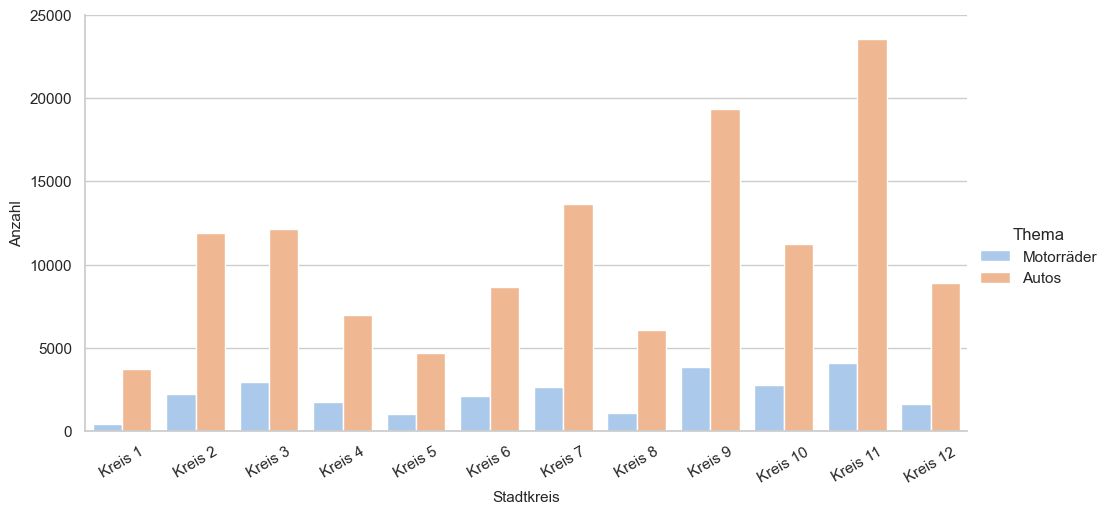

In [129]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="Raum"
            , y="Zahl"
            , hue="Thema"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            #, data=df_verkehr.query("RaumNr > 0 and Oberthema=='Verkehr'")
            ,data=data2betested_int.query("(RaumNr > 0 and RaumNr < 99 ) and (Thema == 'Autos' or Thema == 'Motorräder')")
           )
myHist.set_xticklabels(rotation=30) 
myHist.set_xlabels('Stadtkreis', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl', fontsize=11)
myHist.set(ylim=(0, 25000))


### Vergleiche INT und PROD in einem Dataframe

In [130]:
# DataFrames zusammenführen
merged_df = pd.merge(
    data2betested,
    data2betested_int,
    on=['Oberthema', 'Thema', 'RaumNr'],
    suffixes=('_prod', '_int')
)

In [131]:
merged_df['Zahl_Differenz'] = merged_df['Zahl_int'] - merged_df['Zahl_prod']
merged_df.columns

Index(['RaumNr', 'Raum_prod', 'Oberthema', 'Zahl_prod', 'Thema', 'Vergleichszahl_prod',
       'Vergleichstext_prod', 'Bemerkungen_prod', 'Raum_int', 'Zahl_int', 'Vergleichszahl_int',
       'Vergleichstext_int', 'Bemerkungen_int', 'Zahl_Differenz'],
      dtype='object')

In [137]:
vergleichs_df = merged_df[['RaumNr', 'Raum_prod', 'Oberthema', 'Thema','Zahl_prod','Zahl_int', 'Zahl_Differenz']]


In [142]:
vergleichs_df.query("Zahl_prod != Zahl_int").T

,59,80,93,140,141,145,147,...,2040,2041,2043,2044,2047,2048,2050
RaumNr,12,740,1230,1230,0,4,6,...,420,440,520,610,720,730,810
Raum_prod,Kreis 12,Witikon,Hirzenbach,Hirzenbach,Ganze Stadt,Kreis 4,Kreis 6,...,Langstrasse,Hard,Escher Wyss,Unterstrass,Hottingen,Hirslanden,Seefeld
Oberthema,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,Stadtgebiet,...,Verkehr,Verkehr,Verkehr,Verkehr,Verkehr,Verkehr,Verkehr
Thema,Anteil der Waldfläche in %,Anteil der Waldfläche in %,Anteil der Waldfläche in %,Anteil der Gewässerfläche in %,Brunnen,Brunnen,Brunnen,...,Zweiradabstellplätze,Zweiradabstellplätze,Zweiradabstellplätze,Zweiradabstellplätze,Zweiradabstellplätze,Zweiradabstellplätze,Zweiradabstellplätze
Zahl_prod,29,42,14,0,1274,66,104,...,160,67,114,88,37,17,34
Zahl_int,29,42,13,0,1283,67,105,...,163,71,115,89,38,18,36
Zahl_Differenz,-0,0,-0,0,9,1,1,...,3,4,1,1,1,1,2


--- Testing stopped here

#### Faced Grids

In [134]:
data2betested.columns

Index(['RaumNr', 'Raum', 'Oberthema', 'Zahl', 'Thema', 'Vergleichszahl', 'Vergleichstext',
       'Bemerkungen'],
      dtype='object')

In [135]:
myFG = data2betested.query('HerkunftLang !="Ausland"')\
    .groupby(['StichtagDatJahr', 'QuarLang', 'QuarCd','ZuzKtHistCd', 'ZuzKtHistLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('QuarCd', ascending=True) 
myFG

UndefinedVariableError: name 'HerkunftLang' is not defined

In [ ]:
data2betested.columns

Index(['AlterV10Cd', 'AlterV10Lang', 'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang',
       'QuarCd', 'QuarLang', 'ZuzKtHistCd', 'ZuzKtHistLang', 'ZuzBezirkHistCd',
       'ZuzBezirkHistLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

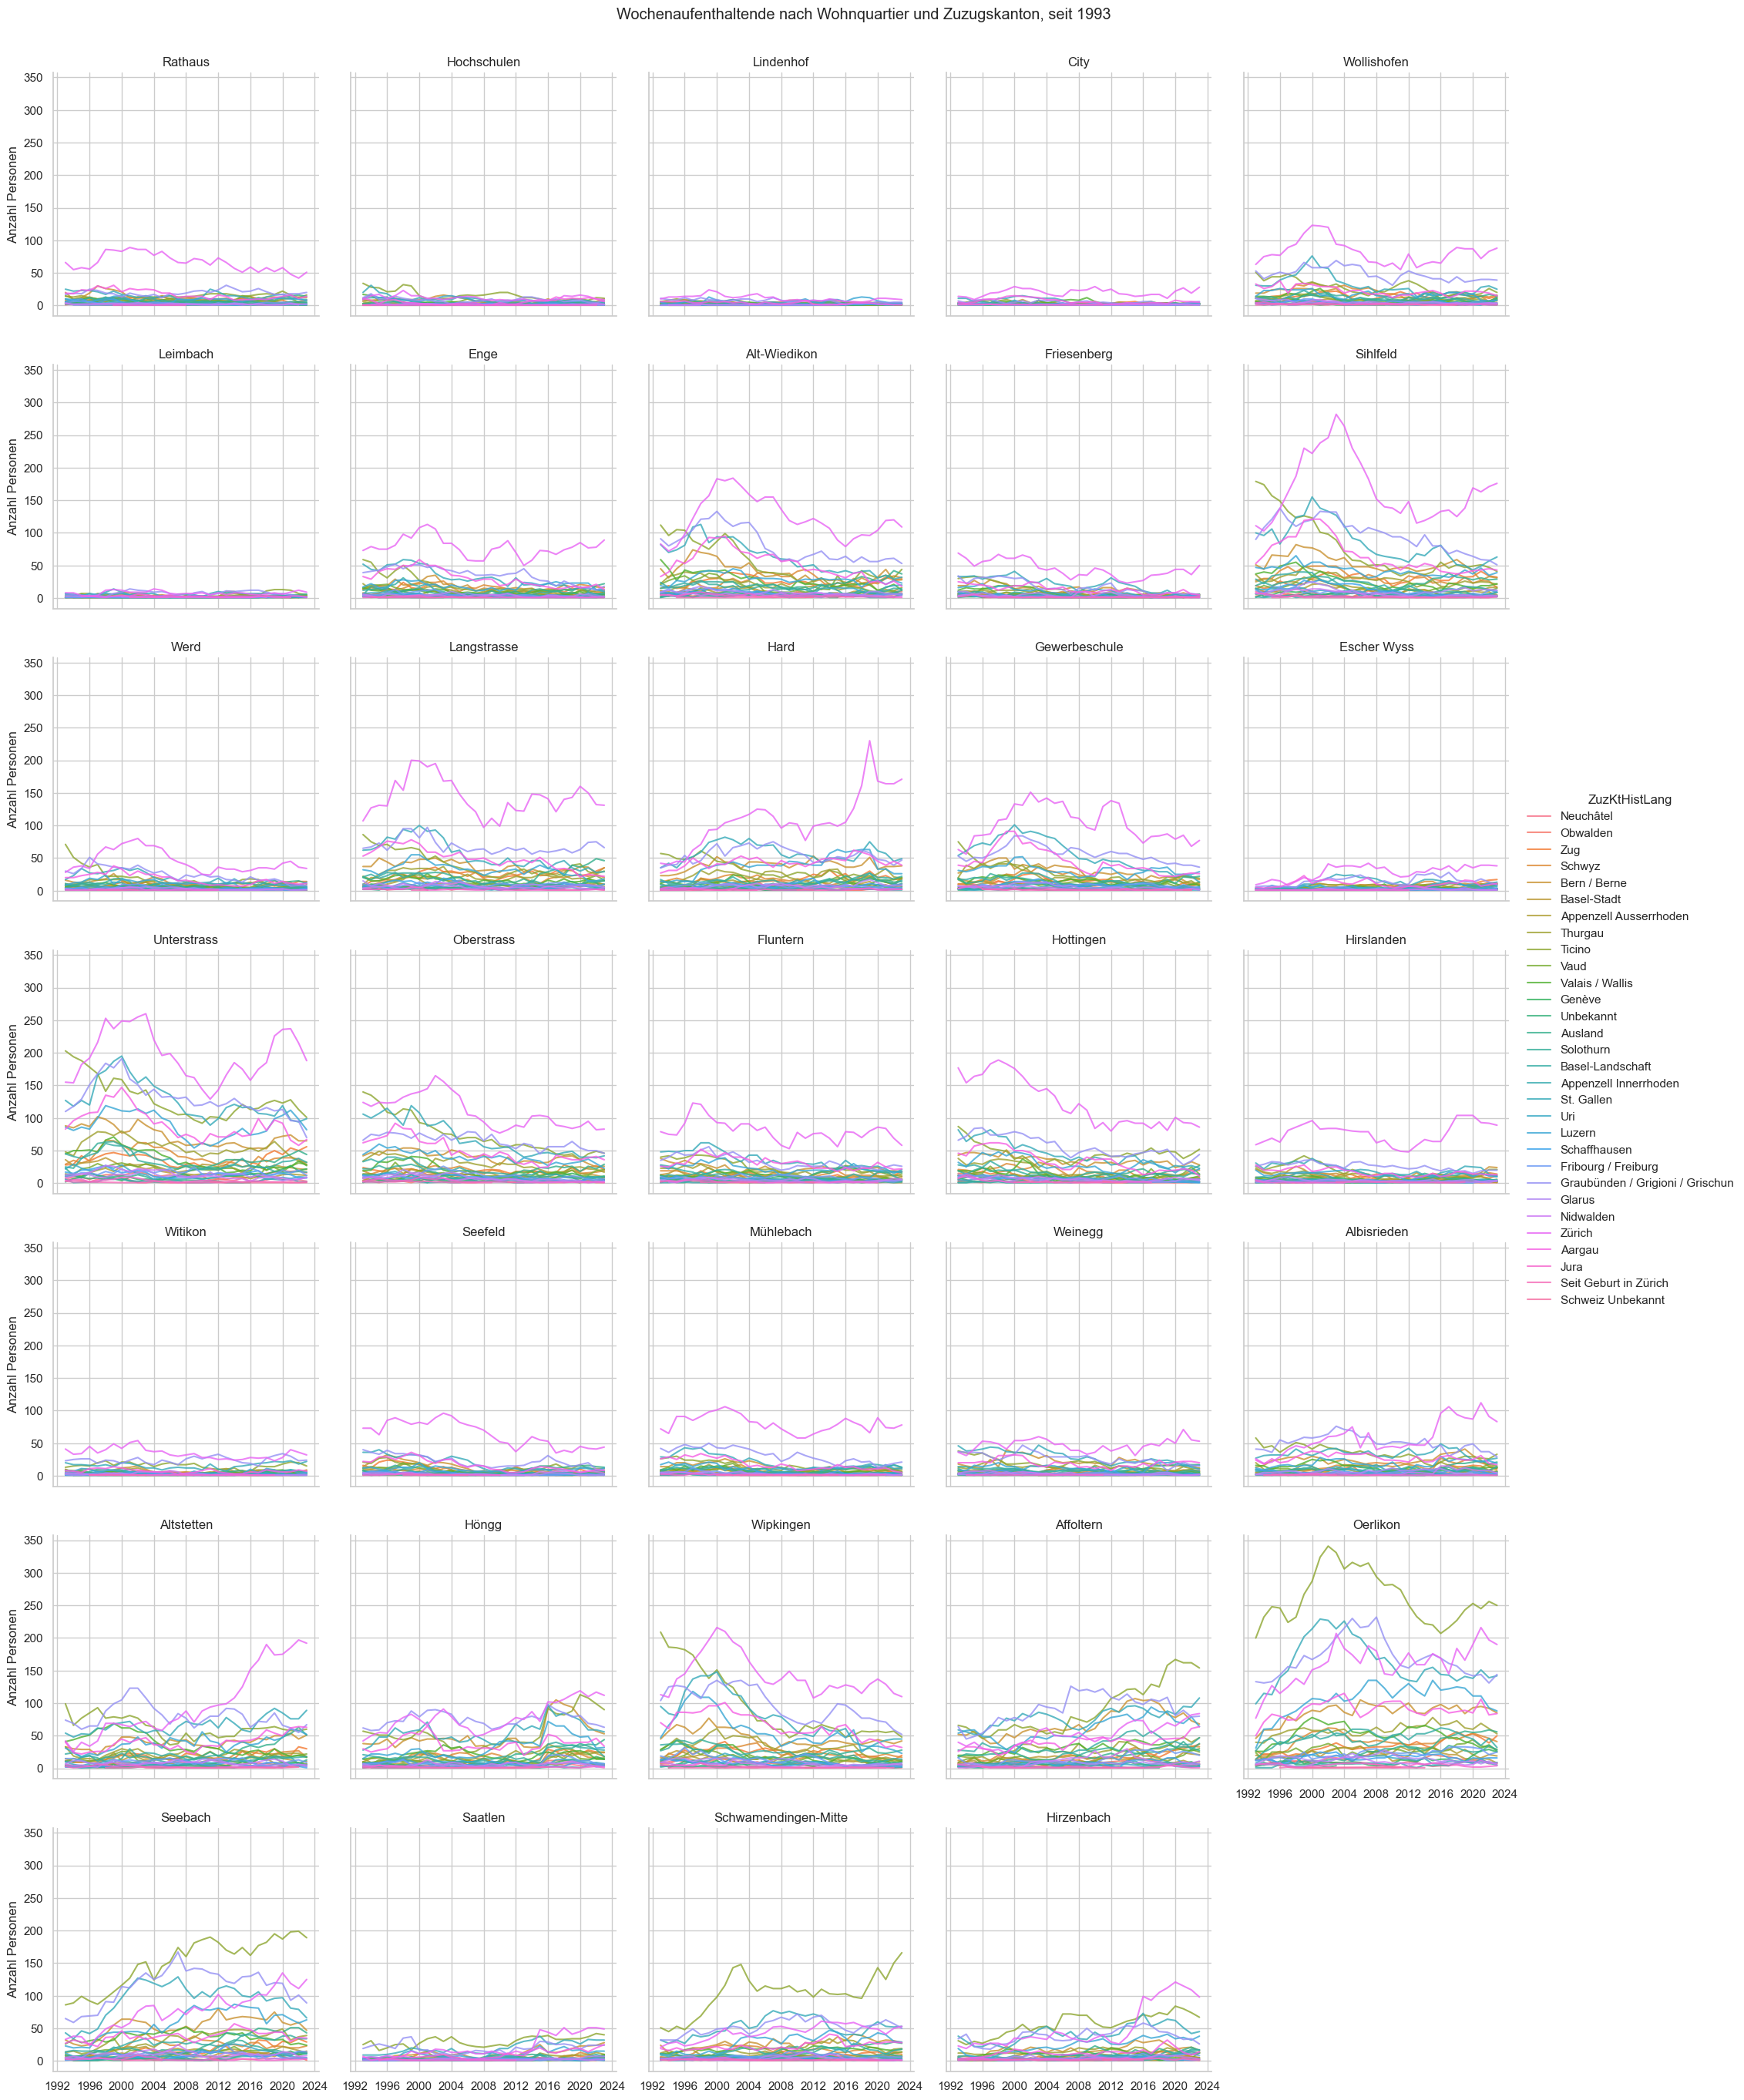

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarCd', ascending=True)
    ,col = "QuarLang"
    ,hue = "ZuzKtHistLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wochenaufenthaltende nach Wohnquartier und Zuzugskanton, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

##### Wochenaufenthaltende nach Altersgruppe und Zuzugskanton

In [ ]:
data2betested.columns

Index(['AlterV10Cd', 'AlterV10Lang', 'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang',
       'QuarCd', 'QuarLang', 'ZuzKtHistCd', 'ZuzKtHistLang', 'ZuzBezirkHistCd',
       'ZuzBezirkHistLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [ ]:
myFG2 = data2betested.query('AlterV10Cd>10')\
    .groupby(['StichtagDatJahr', 'AlterV10Cd', 'AlterV10Lang','ZuzKtHistCd', 'ZuzKtHistLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('AlterV10Cd', ascending=True) 
myFG2

sum_WBev
StichtagDatJahr AlterV10Cd AlterV10Lang           ZuzKtHistCd ZuzKtHistLang             
1993-01-01      20         20- bis 29-Jährige     1           Zürich                1367
2005-01-01      20         20- bis 29-Jährige     14          Schaffhausen           144
                                                  13          Basel-Landschaft       365
                                                  12          Basel-Stadt            181
                                                  11          Solothurn              235
...                                                                                  ...
2016-01-01      100        100-Jährige und Ältere 1           Zürich                   1
                                                  23          Valais / Wallis          1
2017-01-01      100        100-Jährige und Ältere 23          Valais / Wallis          1
2022-01-01      100        100-Jährige und Ältere 1           Zürich                   1
2023-01-01      100        100-Jährige und Ältere 1           Zürich                   1

[5165 rows x 1 columns]

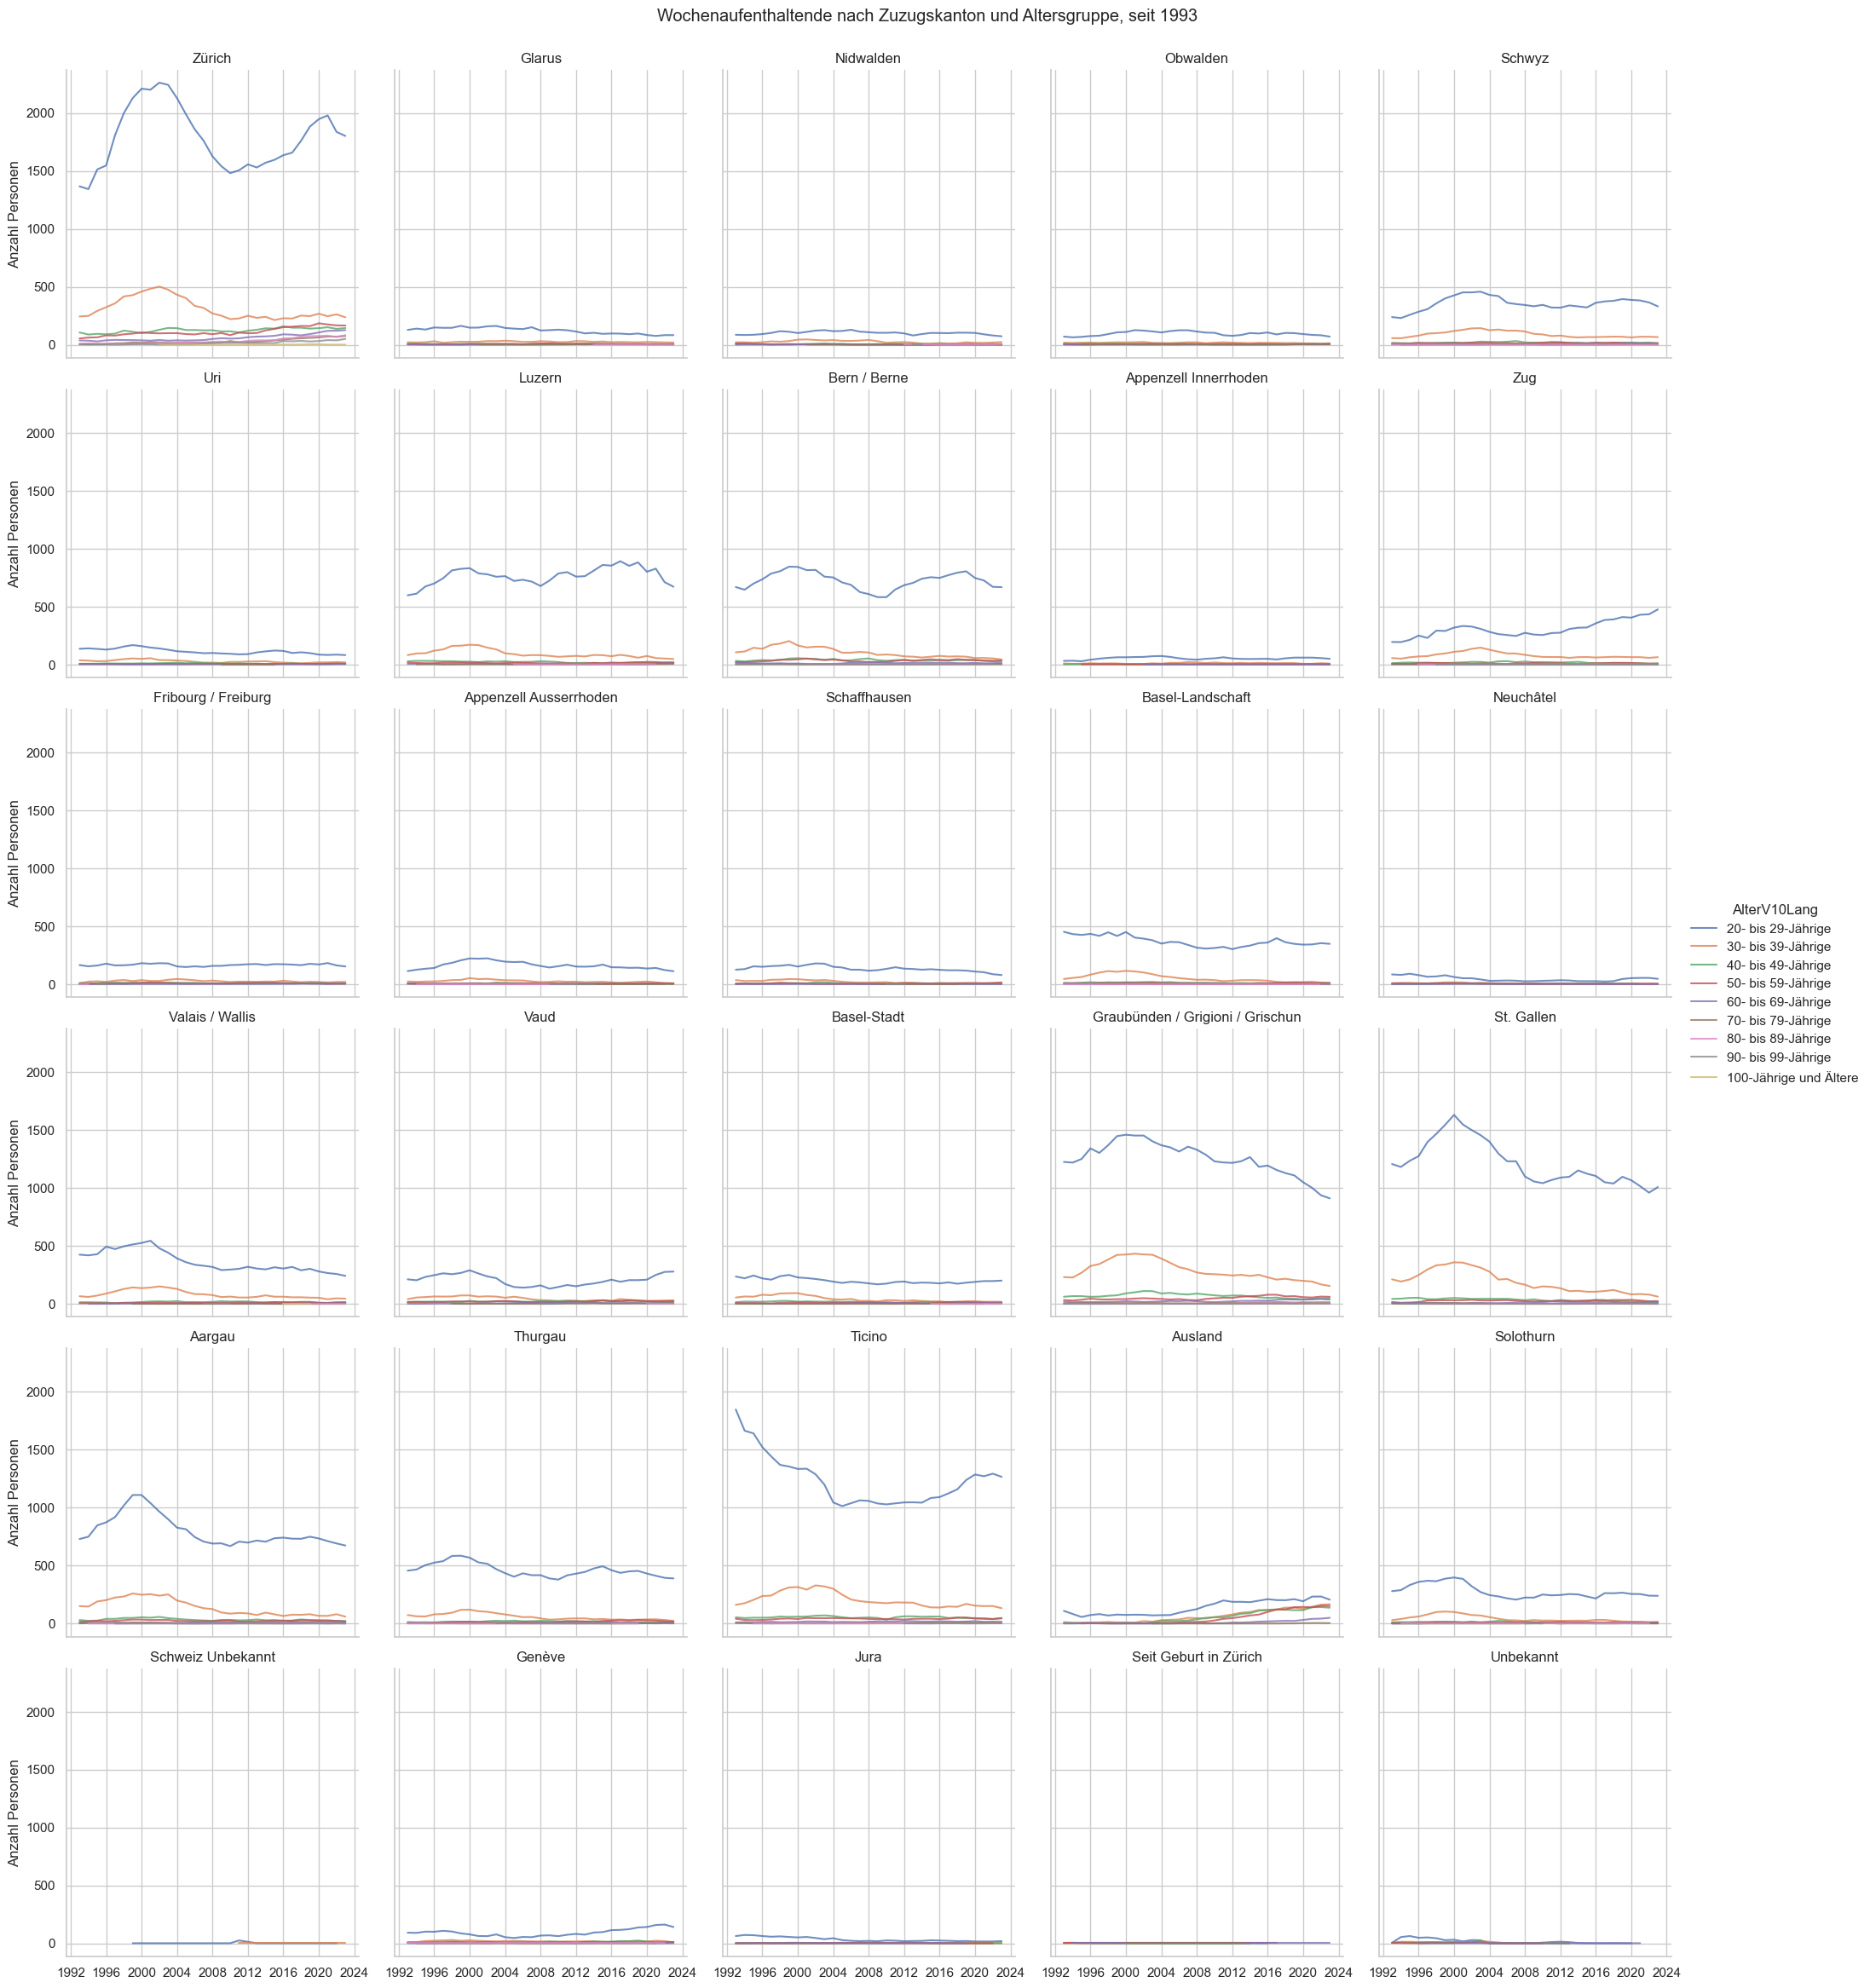

In [ ]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('AlterV10Cd', ascending=True)
    ,col = "ZuzKtHistLang"
    ,hue = "AlterV10Lang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wochenaufenthaltende nach Zuzugskanton und Altersgruppe, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['ZuzKtHistLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'St. Gallen': '#A30059', 'Zürich': '#DB247D', 'Schwyz': '#FF579E', 'Graubünden / Grigioni / Grischun': '#FFA8D0', 'Seit Geburt in Zürich': '#E4E0DF', 'Bern / Berne': '#A8DBB1', 'Valais / Wallis': '#55BC5D', 'Fribourg / Freiburg': '#1F9E31', 'Aargau': '#10652A', 'Thurgau': '#0017BF', 'Basel-Stadt': '#0072D7', 'Basel-Landschaft': '#00A5D2', 'Ticino': '#5E359A', 'Vaud': '#BA0062', 'Jura': '#DA5563', 'Zug': '#00615D', 'Uri': '#00770F', 'Luzern': '#7BA600', 'Solothurn': '#7B4100', 'Appenzell Ausserrhoden': '#DC5500', 'Obwalden': '#DA9C00', 'Neuchâtel': '#5D4BFE', 'Glarus': '#4AA9FF', 'Schaffhausen': '#55FFFF', 'Genève': '#986AD5', 'Nidwalden': '#FC4C99', 'Unbekannt': '#FF919A', 'Ausland': '#349894', 'Appenzell Innerrhoden': '#44B14A', 'Schweiz Unbekannt': '#B7E14E'}


##### Wochenaufenthaltende nach Zuzugsgebiet

In [ ]:
data2betested.columns

Index(['AlterV10Cd', 'AlterV10Lang', 'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang',
       'QuarCd', 'QuarLang', 'ZuzKtHistCd', 'ZuzKtHistLang', 'ZuzBezirkHistCd',
       'ZuzBezirkHistLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [ ]:
myTM = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'ZuzKtHistLang', 'ZuzBezirkHistLang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 

myTM.reset_index().head(2)

,StichtagDatJahr,ZuzKtHistLang,ZuzBezirkHistLang,AnzBestWir
0,2023-01-01,Ticino,Distretto di Lugano,788
1,2023-01-01,Ausland,Ausland,738


In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['ZuzKtHistLang','ZuzBezirkHistLang']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet, "+data_max_date
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001AE8581CE90>, 'ZuzKtHistLang', 'ZuzBezirkHistLang']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet

In [ ]:
myTM2 = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'ZuzKtHistLang', 'ZuzBezirkHistLang', 'AlterV10Lang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 
myTM2.reset_index().head(2)

,StichtagDatJahr,ZuzKtHistLang,ZuzBezirkHistLang,AlterV10Lang,AnzBestWir
0,2023-01-01,Ticino,Distretto di Lugano,20- bis 29-Jährige,610
1,2023-01-01,Zug,Kanton Zug,20- bis 29-Jährige,475


In [ ]:
#agg_age
#agg_age.reset_index().dtypes

In [ ]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM2.reset_index()
    ,levels=['AlterV10Lang', 'ZuzKtHistLang','ZuzBezirkHistLang']
    ,values="AnzBestWir"
    ,color="ZuzKtHistLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Altersgruppe und Zuzugsgebiet, "+data_max_date
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000001AE853DB850>, 'AlterV10Lang', 'ZuzKtHistLang', 'ZuzBezirkHistLang']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Zuzugsgebiet und Wohnquartier 

In [ ]:
myTM3 = data2betested.loc[data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'ZuzKtHistLang', 'ZuzBezirkHistLang', 'QuarLang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 
myTM3.reset_index().head(2)

,StichtagDatJahr,ZuzKtHistLang,ZuzBezirkHistLang,QuarLang,AnzBestWir
0,2023-01-01,Ticino,Distretto di Lugano,Oerlikon,142
1,2023-01-01,Ticino,Distretto di Lugano,Seebach,86


In [ ]:
treeMap3= mypy_dv.plot_px_treemap(
    data=myTM3.reset_index()
    ,levels=['ZuzKtHistLang', 'QuarLang']
    ,values="AnzBestWir"
    ,color="ZuzKtHistLang"
    #, color_continuous_scale='Blues'
    , color_discrete_map=farben_dict_zc                            
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet und Wohnquartier "+data_max_date
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x000001AEF176CB10>, 'ZuzKtHistLang', 'QuarLang']
Typ von path: <class 'list'>


In [ ]:
treeMap4= mypy_dv.plot_px_treemap(
    data=myTM3.query('ZuzKtHistLang != "Zürich"').reset_index()
    ,levels=['ZuzKtHistLang', 'QuarLang']
    ,values="AnzBestWir"
    ,color="ZuzKtHistLang"
    #, color_continuous_scale='Blues'
    , color_discrete_map=farben_dict_zc                            
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet (ohne KT ZH) und Wohnquartier "+data_max_date
)
treeMap4

path: [<plotly.express._special_inputs.Constant object at 0x000001AEF5DE88D0>, 'ZuzKtHistLang', 'QuarLang']
Typ von path: <class 'list'>


##### Wochenaufenthaltende nach Zuzugsgebiet und Jahr

In [ ]:
myTM5 = data2betested.loc["2010":data_max_date].reset_index() \
    .groupby(['StichtagDatJahr', 'ZuzKtHistLang', 'ZuzBezirkHistLang']) \
    .agg(AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AnzBestWir', ascending=False) 
myTM5.reset_index().head(2)

,StichtagDatJahr,ZuzKtHistLang,ZuzBezirkHistLang,AnzBestWir
0,2020-01-01,Ticino,Distretto di Lugano,791
1,2023-01-01,Ticino,Distretto di Lugano,788


In [ ]:
treeMap5= mypy_dv.plot_px_treemap(
    data=myTM5.query('ZuzKtHistLang != "Zürich"').reset_index()
    ,levels=['StichtagDatJahr', 'ZuzKtHistLang',]
    ,values="AnzBestWir"
    ,color="ZuzKtHistLang"
    #, color_continuous_scale='Blues'
    , color_discrete_map=farben_dict_zc                            
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Jahr und Zuzugsgebiet "+data_max_date
)
treeMap5

path: [<plotly.express._special_inputs.Constant object at 0x000001AEF2ADE890>, 'StichtagDatJahr', 'ZuzKtHistLang']
Typ von path: <class 'list'>


In [ ]:
treeMap6= mypy_dv.plot_px_treemap(
    data=myTM5.query('ZuzKtHistLang != "Zürich"').reset_index()
    ,levels=['ZuzKtHistLang','StichtagDatJahr', ]
    ,values="AnzBestWir"
    ,color="ZuzKtHistLang"
    #, color_continuous_scale='Blues'
    , color_discrete_map=farben_dict_zc                            
    ,height=500
    ,width=1000             
    #,margin_val_bottom=25
    ,myHeaderTitle="Wochenaufenthaltende nach Zuzugsgebiet und Jahr "+data_max_date
)
treeMap6

path: [<plotly.express._special_inputs.Constant object at 0x000001AEF4332F10>, 'ZuzKtHistLang', 'StichtagDatJahr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1009&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------